# Alpamayo 2 Super Meta-Action Inference

Run this notebook from the repository root with the `Alpamayo 2 Super` kernel. Set `ALPAMAYO2_SUPER_MODEL_ID` to a Hugging Face model id or local release checkpoint before starting the kernel. The notebook selects the validated six-camera/four-frame meta-action input profile before model preparation.

In [1]:
import os

os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

'expandable_segments:True'

In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from IPython.display import display

from alpamayo2_super import helper
from alpamayo2_super.common.constants import PUBLIC_MODEL_ID
from alpamayo2_super.inference_smoke import resolve_project_path, validate_model_id
from alpamayo2_super.input_profiles import select_task_input
from alpamayo2_super.load_physical_aiavdataset import load_physical_aiavdataset
from alpamayo2_super.models.alpamayo2_super import Alpamayo2Super
from alpamayo2_super.text_tasks import generate_text, prepare_text_generation_inputs
from alpamayo2_super.visualization import plot_meta_action_result

In [3]:
cwd = Path.cwd()
if (cwd / "examples").exists():
    project_root = cwd
elif (cwd.parent / "examples").exists():
    project_root = cwd.parent
else:
    project_root = cwd

MODEL_ID = os.environ.get("ALPAMAYO2_SUPER_MODEL_ID", PUBLIC_MODEL_ID)
MANIFEST = resolve_project_path(
    os.environ.get("ALPAMAYO2_SUPER_VALIDATION_MANIFEST", "examples/validation_samples.json"),
    project_root,
)
SAMPLE_INDEX = int(os.environ.get("ALPAMAYO2_SUPER_SAMPLE_INDEX", "0"))
MAX_NEW_TOKENS = int(os.environ.get("ALPAMAYO2_SUPER_META_ACTION_MAX_NEW_TOKENS", "512"))
SEED = int(os.environ.get("ALPAMAYO2_SUPER_SEED", "42"))
OUTPUT_DIR = resolve_project_path(
    os.environ.get("ALPAMAYO2_SUPER_OUTPUT_DIR", "outputs"), project_root
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sample = json.loads(MANIFEST.read_text(encoding="utf-8"))["samples"][SAMPLE_INDEX]
clip_id = os.environ.get("ALPAMAYO2_SUPER_CLIP_ID", sample["clip_id"])
t0_us = int(os.environ.get("ALPAMAYO2_SUPER_T0_US", str(sample["t0_us"])))
validate_model_id(MODEL_ID)
if not torch.cuda.is_available():
    raise RuntimeError("Alpamayo 2 Super meta-action inference requires a CUDA GPU.")

print("model:", MODEL_ID)
print("sample:", SAMPLE_INDEX, clip_id, t0_us)

model: nvidia/Alpamayo2-Super
sample: 0 030c760c-ae38-49aa-9ad8-f5650a545d26 5100000


In [7]:
!source ../env.sh

In [35]:
source_data = load_physical_aiavdataset(
    clip_id,
    t0_us=t0_us,
)
data = select_task_input(source_data, "meta_action")
print("camera_indices:", data["camera_indices"].tolist())

camera_indices: [0, 1, 2, 3, 5, 6]


In [36]:
model = Alpamayo2Super.from_pretrained(MODEL_ID, dtype=torch.bfloat16, device_map="cuda:0")
task_inputs = prepare_text_generation_inputs(
    data=data,
    model_config=model.config,
    tokenizer=model.tokenizer,
    task="meta_action",
)
task_inputs = helper.to_device(task_inputs, "cuda")

Loading checkpoint shards:   0%|          | 0/15 [00:00<?, ?it/s]

In [37]:
torch.cuda.manual_seed_all(SEED)
with torch.autocast("cuda", dtype=torch.bfloat16):
    result = generate_text(
        model,
        task_inputs,
        top_p=0.98,
        temperature=0.6,
        max_new_tokens=MAX_NEW_TOKENS,
    )

cot = result["cot"][0]
meta_action = result["meta_action"][0]
print("Chain-of-Causation:\n", cot)
print("\nMeta-action:\n", meta_action)

Chain-of-Causation:
 Nudge left to pass the roadwork cones encroaching into the lane.

Meta-action:
 Longitudinal: Maintain Speed.
Lateral: Go Straight.
Lane: Lane Keep.


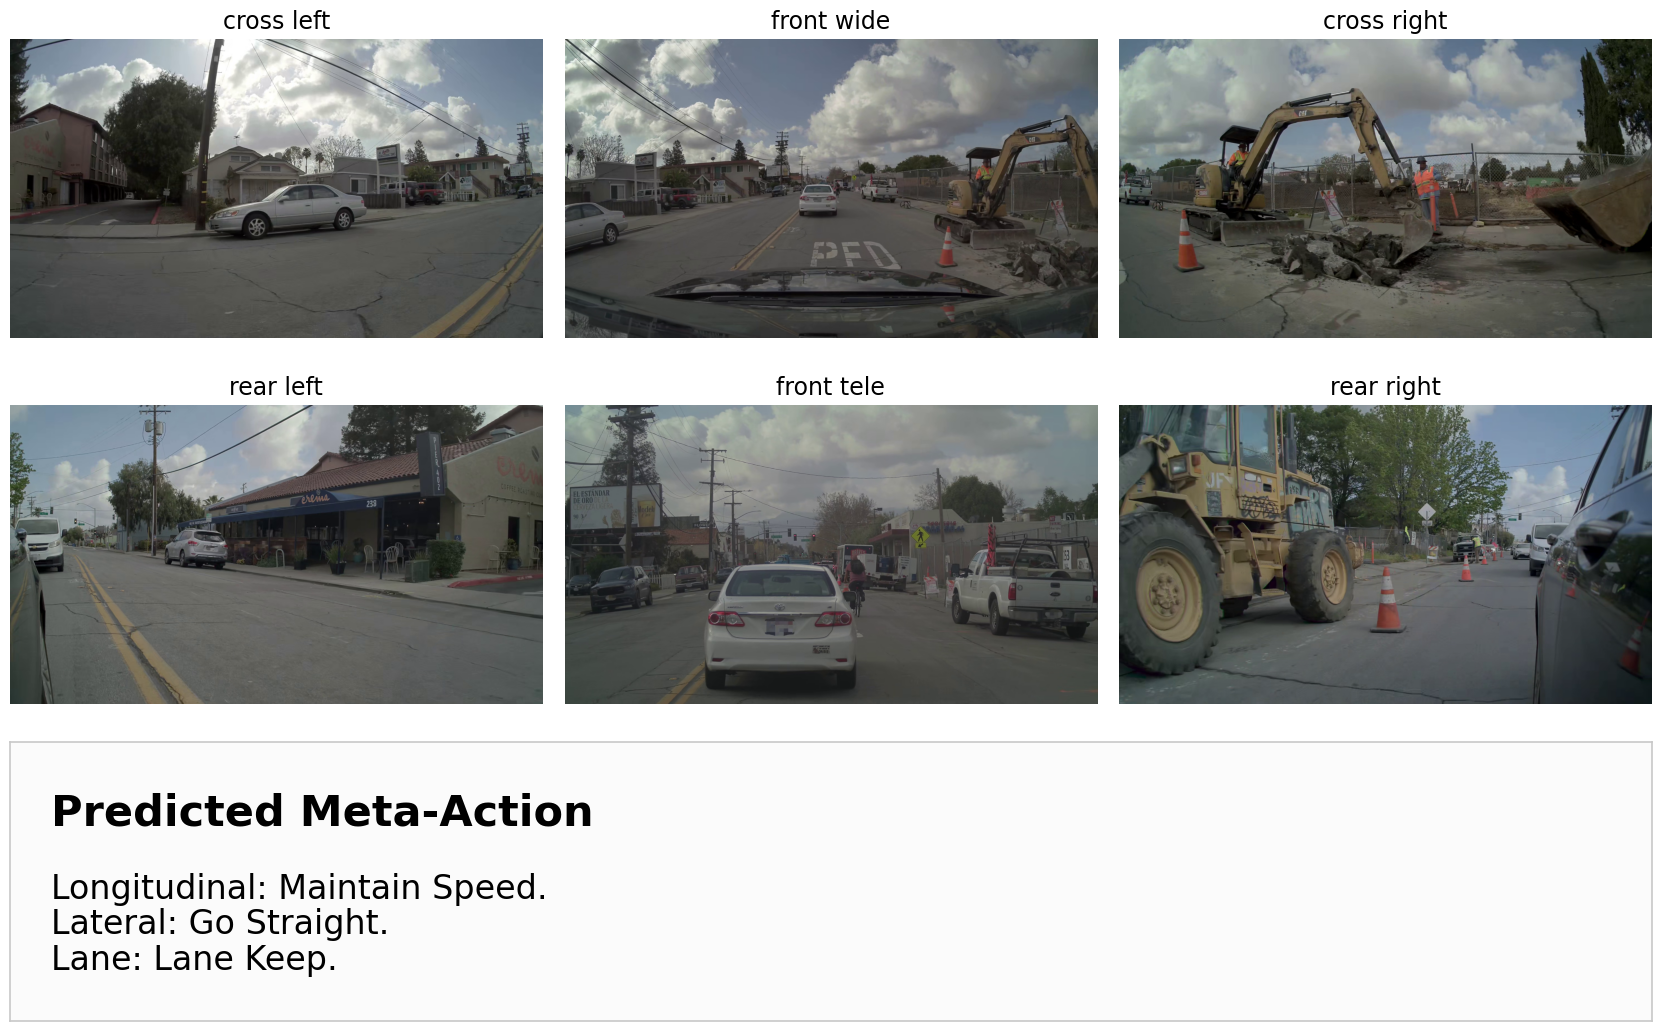

saved_png: /mnt/efs/users/rod/repos/alpamayo2/outputs/meta_action_sample0_030c760c-ae38-49aa-9ad8-f5650a545d26_5100000.png
saved_json: /mnt/efs/users/rod/repos/alpamayo2/outputs/meta_action_sample0_030c760c-ae38-49aa-9ad8-f5650a545d26_5100000.json


In [38]:
artifact_stem = f"meta_action_sample{SAMPLE_INDEX}_{clip_id}_{t0_us}"
figure_path = OUTPUT_DIR / f"{artifact_stem}.png"
json_path = OUTPUT_DIR / f"{artifact_stem}.json"
fig, figure_metadata = plot_meta_action_result(
    data=data,
    cot=cot,
    meta_action=meta_action,
    output_path=figure_path,
    model_id=MODEL_ID,
    seed=SEED,
)
display(fig)
plt.close(fig)
payload = {
    "task": "meta_action",
    "model_id": MODEL_ID,
    "clip_id": clip_id,
    "t0_us": t0_us,
    "seed": SEED,
    "max_new_tokens": MAX_NEW_TOKENS,
    "cot": cot,
    "meta_action": meta_action,
    "raw_output": result["raw_outputs"][0],
    "figure_path": str(figure_path),
    "figure_metadata": figure_metadata,
}
json_path.write_text(json.dumps(payload, indent=2), encoding="utf-8")
print("saved_png:", figure_path)
print("saved_json:", json_path)

## Top-k token probe at each meta-action field boundary

Re-run generation with `output_scores=True` and inspect the model's actual output distribution at the position right after `Longitudinal:`, `Lateral:`, and `Lane:` — i.e. what alternative first-words were plausible for each field, not just the one value that got sampled above.

In [45]:
import copy

from transformers import StoppingCriteriaList
from transformers.generation.logits_process import LogitsProcessorList

from alpamayo2_super.models.alpamayo2_super import MaskDiscreteTrajectoryLogitsProcessor
from alpamayo2_super.models.expert_utils import StopAfterEOS
from alpamayo2_super.models.utils import fuse_traj_tokens

TOP_K_PROBE = 10
FIELD_MARKERS = ["Longitudinal:", "Lateral:", "Lane:"]

tokenized_data = dict(task_inputs["tokenized_data"])
traj_data = {
    "ego_history_xyz": task_inputs["ego_history_xyz"],
    "ego_history_rot": task_inputs["ego_history_rot"],
}
tokenized_data["input_ids"] = fuse_traj_tokens(
    model.history_traj_tokenizer,
    model.future_traj_tokenizer,
    tokenized_data["input_ids"],
    traj_data,
    model.config.traj_ids,
)
prompt_length = tokenized_data["input_ids"].shape[1]

generation_config = copy.deepcopy(model.vlm.generation_config)
generation_config.top_p = 0.98
generation_config.temperature = 0.6
generation_config.do_sample = True
generation_config.num_return_sequences = 1
generation_config.max_new_tokens = MAX_NEW_TOKENS
generation_config.output_scores = True
generation_config.return_dict_in_generate = True
generation_config.pad_token_id = model.tokenizer.pad_token_id

logits_processor = LogitsProcessorList(
    [
        MaskDiscreteTrajectoryLogitsProcessor(
            traj_token_offset=min(
                model.config.traj_ids["history_id0"], model.config.traj_ids["future_id0"]
            ),
            traj_vocab_size=model.config.traj_vocab_size,
        )
    ]
)
stopping_criteria = StoppingCriteriaList(
    [StopAfterEOS(eos_token_id=model.config.traj_ids["future_start"])]
)

torch.cuda.manual_seed_all(SEED)
with torch.autocast("cuda", dtype=torch.bfloat16):
    probe_outputs = model.vlm.generate(
        **tokenized_data,
        generation_config=generation_config,
        logits_processor=logits_processor,
        stopping_criteria=stopping_criteria,
    )

generated_tokens = probe_outputs.sequences[0, prompt_length:].tolist()
# probe_outputs.scores[t] is the post-processor, post-warp distribution the sampler actually
# drew generated_tokens[t] from -- same top_p/temperature policy as the generation above.
step_scores = probe_outputs.scores

# Find the first generation step whose cumulative decoded text contains each field marker,
# then inspect the distribution over the *next* token: the first word of the value the
# model is about to commit to for that field.
boundaries = {}
cumulative_ids: list[int] = []
for step, token_id in enumerate(generated_tokens):
    cumulative_ids.append(token_id)
    decoded_so_far = model.tokenizer.decode(cumulative_ids, skip_special_tokens=False)
    for marker in FIELD_MARKERS:
        if marker not in boundaries and marker in decoded_so_far:
            boundaries[marker] = step

for marker in FIELD_MARKERS:
    step = boundaries.get(marker)
    if step is None or step + 1 >= len(step_scores):
        print(f"{marker} not found in this generation")
        continue
    probs = torch.softmax(step_scores[step + 1][0].float(), dim=-1)
    top_probs, top_ids = torch.topk(probs, TOP_K_PROBE)
    print(f"\nTop-{TOP_K_PROBE} candidates for the first token after '{marker}':")
    for prob, token_id in zip(top_probs.tolist(), top_ids.tolist()):
        print(f"  {prob:.3f}  {model.tokenizer.decode([token_id])!r}")


Top-10 candidates for the first token after 'Longitudinal:':
  0.938  ' Gentle'
  0.062  ' Maintain'
  0.000  '!'
  0.000  '"'
  0.000  "'"
  0.000  '('
  0.000  '&'
  0.000  '%'
  0.000  '#'
  0.000  '$'

Top-10 candidates for the first token after 'Lateral:':
  1.000  ' Go'
  0.000  '"'
  0.000  '$'
  0.000  "'"
  0.000  '('
  0.000  '!'
  0.000  '#'
  0.000  '&'
  0.000  ')'
  0.000  '%'

Top-10 candidates for the first token after 'Lane:':
  0.552  ' S'
  0.448  ' Lane'
  0.000  '!'
  0.000  '"'
  0.000  "'"
  0.000  '('
  0.000  '&'
  0.000  '%'
  0.000  '#'
  0.000  '$'


## Teacher-forced log-probs for specific candidate phrases

Rather than reading off the top-k next token, force each full candidate phrase (e.g. `"Strong Decelerate."`) as the completion after the field marker and sum the model's own token log-probs for it. This directly answers "how likely does the model consider *this exact phrase*", including multi-token phrases the top-k-single-token view above can't show. Depends on `tokenized_data`, `generated_tokens`, and `boundaries` from the previous cell — run that first.

Ranking is surface-form sensitive: wording, capitalization, and punctuation that don't match the model's own convention will score lower for reasons unrelated to whether the maneuver itself is plausible. Edit the candidate lists below to try other phrasings.

In [46]:
import math

import torch.nn.functional as F

LONGITUDINAL_CANDIDATES = [
    "Gentle accelerate",
    "Strong accelerate",
    "Gentle decelerate",
    "Strong decelerate",
    "Maintain speed",
    "Stop",
    "Reverse",
]
LATERAL_CANDIDATES = [
    "Steer left",
    "Steer right",
    "Sharp steer left",
    "Sharp steer right",
    "Reverse left",
    "Reverse right",
    "Go straight",
]


def normalize_field_value(text: str) -> str:
    """Title-case each word to match the model's observed 'Gentle Deceleration.' style."""
    return " ".join(word.capitalize() for word in text.split())


def extract_actual_field_value(meta_action_text: str, field_name: str) -> str | None:
    """Pull the model's own generated value for one field, to use as a scoring control."""
    prefix = f"{field_name}:"
    for line in meta_action_text.splitlines():
        stripped = line.strip()
        if stripped.startswith(prefix):
            return stripped[len(prefix) :].strip().rstrip(".")
    return None


prompt_ids = tokenized_data["input_ids"][0].tolist()
shared_forward_kwargs = {
    key: value for key, value in tokenized_data.items() if key not in ("input_ids", "attention_mask")
}


def score_candidate(prefix_ids: list[int], candidate_text: str) -> tuple[float, float, int]:
    """Teacher-force ``candidate_text`` after ``prefix_ids``; return (total, mean, n_tokens) log-probs.

    Appends ".\\n" rather than "." -- the tokenizer merges period+newline into one token
    (id 624) at the end of a non-final field line, so a bare "." re-tokenizes to a different,
    near-impossible token and silently tanks the whole score regardless of candidate wording.
    """
    candidate_ids = model.tokenizer(
        " " + normalize_field_value(candidate_text) + ".\n", add_special_tokens=False
    )["input_ids"]
    full_ids = torch.tensor([prefix_ids + candidate_ids], device=model.vlm.device)
    attention_mask = torch.ones_like(full_ids)
    with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
        logits = model.vlm(
            input_ids=full_ids, attention_mask=attention_mask, **shared_forward_kwargs
        ).logits
    start = len(prefix_ids)
    pred_logits = logits[0, start - 1 : start - 1 + len(candidate_ids)].float()
    token_log_probs = F.log_softmax(pred_logits, dim=-1).gather(
        -1, full_ids[0, start : start + len(candidate_ids)].unsqueeze(-1)
    ).squeeze(-1)
    return token_log_probs.sum().item(), token_log_probs.mean().item(), len(candidate_ids)


def report_candidates(
    field_name: str, prefix_ids: list[int], candidates: list[str], actual_value: str | None
) -> None:
    # Score the model's own generated value alongside the hypotheses. If it doesn't land near
    # the top, the candidate wording -- not the maneuver -- is what's being penalized.
    all_candidates = list(candidates)
    if actual_value and actual_value not in all_candidates:
        all_candidates.append(actual_value)

    print(f"\n{field_name} candidates given the actual generated context up to '{field_name}:':")
    scored = [(candidate, *score_candidate(prefix_ids, candidate)) for candidate in all_candidates]
    for candidate, total, mean, n_tokens in sorted(scored, key=lambda row: row[2], reverse=True):
        tag = "  <- actual generation" if candidate == actual_value else ""
        print(
            f"  mean_logprob={mean:7.3f} (~{math.exp(mean):.3f}/token)  "
            f"total_logprob={total:7.3f}  n_tokens={n_tokens}  {candidate!r}{tag}"
        )


longitudinal_prefix = prompt_ids + generated_tokens[: boundaries["Longitudinal:"] + 1]
lateral_prefix = prompt_ids + generated_tokens[: boundaries["Lateral:"] + 1]

report_candidates(
    "Longitudinal",
    longitudinal_prefix,
    LONGITUDINAL_CANDIDATES,
    extract_actual_field_value(meta_action, "Longitudinal"),
)
report_candidates(
    "Lateral",
    lateral_prefix,
    LATERAL_CANDIDATES,
    extract_actual_field_value(meta_action, "Lateral"),
)


Longitudinal candidates given the actual generated context up to 'Longitudinal:':
  mean_logprob= -0.568 (~0.566/token)  total_logprob= -1.705  n_tokens=3  'Maintain speed'
  mean_logprob= -0.568 (~0.566/token)  total_logprob= -1.705  n_tokens=3  'Maintain Speed'  <- actual generation
  mean_logprob= -5.089 (~0.006/token)  total_logprob=-25.443  n_tokens=5  'Gentle decelerate'
  mean_logprob= -6.376 (~0.002/token)  total_logprob=-25.505  n_tokens=4  'Gentle accelerate'
  mean_logprob= -6.485 (~0.002/token)  total_logprob=-32.426  n_tokens=5  'Strong decelerate'
  mean_logprob= -6.982 (~0.001/token)  total_logprob=-27.926  n_tokens=4  'Strong accelerate'
  mean_logprob=-16.010 (~0.000/token)  total_logprob=-32.020  n_tokens=2  'Reverse'
  mean_logprob=-17.642 (~0.000/token)  total_logprob=-35.283  n_tokens=2  'Stop'

Lateral candidates given the actual generated context up to 'Lateral:':
  mean_logprob= -0.025 (~0.976/token)  total_logprob= -0.074  n_tokens=3  'Go straight'
  mean_logp

## Sanity check: does direct forward scoring agree with what generation itself saw?

Before trusting any candidate ranking above, verify the `model.vlm(...)` forward call used by `score_candidate` reproduces the probability `generate()` itself assigned to the token it actually sampled at each field boundary. If `direct_forward_prob` is far below `generation_prob` for the model's own real token, the scoring pipeline has a bug (most likely a missing/incorrect kwarg for position encoding) — and the low scores in the candidate table are an artifact of that bug, not evidence about maneuver plausibility.

In [47]:
for marker in FIELD_MARKERS:
    step = boundaries.get(marker)
    if step is None or step + 1 >= len(step_scores):
        continue
    actual_next_token_id = generated_tokens[step + 1]
    generation_prob = torch.softmax(step_scores[step + 1][0].float(), dim=-1)[
        actual_next_token_id
    ].item()

    prefix_ids = prompt_ids + generated_tokens[: step + 1]
    full_ids = torch.tensor([prefix_ids + [actual_next_token_id]], device=model.vlm.device)
    attention_mask = torch.ones_like(full_ids)
    with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
        logits = model.vlm(
            input_ids=full_ids, attention_mask=attention_mask, **shared_forward_kwargs
        ).logits
    raw_prob = torch.softmax(logits[0, len(prefix_ids) - 1].float(), dim=-1)[
        actual_next_token_id
    ].item()

    print(
        f"{marker} actual sampled token {model.tokenizer.decode([actual_next_token_id])!r}: "
        f"generation_prob(post-warp)={generation_prob:.3f}  direct_forward_prob(raw)={raw_prob:.3f}"
    )

Longitudinal: actual sampled token ' Maintain': generation_prob(post-warp)=0.062  direct_forward_prob(raw)=0.182
Lateral: actual sampled token ' Go': generation_prob(post-warp)=1.000  direct_forward_prob(raw)=0.932
Lane: actual sampled token ' Lane': generation_prob(post-warp)=0.448  direct_forward_prob(raw)=0.455


## Does re-tokenizing the actual value match what the model really generated?

The candidate table's `<- actual generation` control scored identically to a hand-typed paraphrase because both go through the same text -> token re-encoding path, not the real sampled IDs. Score the true `generated_tokens` directly (no re-tokenization) for the same span, and compare those IDs token-by-token against re-tokenizing the decoded text from scratch. If the IDs differ despite decoding to the same string, that's why the earlier "actual generation" score looked just as bad as every paraphrase.

In [48]:
def score_token_ids(prefix_ids: list[int], continuation_ids: list[int]) -> tuple[float, float]:
    """Teacher-force a literal continuation (no re-tokenization); return (total, mean) log-probs."""
    full_ids = torch.tensor([prefix_ids + continuation_ids], device=model.vlm.device)
    attention_mask = torch.ones_like(full_ids)
    with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
        logits = model.vlm(
            input_ids=full_ids, attention_mask=attention_mask, **shared_forward_kwargs
        ).logits
    start = len(prefix_ids)
    pred_logits = logits[0, start - 1 : start - 1 + len(continuation_ids)].float()
    token_log_probs = F.log_softmax(pred_logits, dim=-1).gather(
        -1, full_ids[0, start : start + len(continuation_ids)].unsqueeze(-1)
    ).squeeze(-1)
    return token_log_probs.sum().item(), token_log_probs.mean().item()


for marker, field_name in [("Longitudinal:", "Longitudinal"), ("Lateral:", "Lateral")]:
    step = boundaries[marker]
    actual_value = extract_actual_field_value(meta_action, field_name)
    candidate_ids = model.tokenizer(
        " " + normalize_field_value(actual_value) + ".", add_special_tokens=False
    )["input_ids"]
    actual_ids = generated_tokens[step + 1 : step + 1 + len(candidate_ids)]

    print(f"\n{field_name} -- comparing true generated IDs vs re-tokenized text for {actual_value!r}:")
    print("  actual generated ids:     ", actual_ids, [model.tokenizer.decode([t]) for t in actual_ids])
    print("  re-tokenized candidate ids:", candidate_ids, [model.tokenizer.decode([t]) for t in candidate_ids])
    print("  ids match:", actual_ids == candidate_ids)

    prefix_ids = prompt_ids + generated_tokens[: step + 1]
    total, mean = score_token_ids(prefix_ids, actual_ids)
    print(
        f"  scoring the REAL generated ids directly: total={total:.3f} mean={mean:.3f} "
        f"(~{math.exp(mean):.3f}/token)"
    )


Longitudinal -- comparing true generated IDs vs re-tokenized text for 'Maintain Speed':
  actual generated ids:      [86377, 15181, 624] [' Maintain', ' Speed', '.\n']
  re-tokenized candidate ids: [86377, 15181, 13] [' Maintain', ' Speed', '.']
  ids match: False
  scoring the REAL generated ids directly: total=-1.705 mean=-0.568 (~0.566/token)

Lateral -- comparing true generated IDs vs re-tokenized text for 'Go Straight':
  actual generated ids:      [5994, 45810, 624] [' Go', ' Straight', '.\n']
  re-tokenized candidate ids: [5994, 45810, 13] [' Go', ' Straight', '.']
  ids match: False
  scoring the REAL generated ids directly: total=-0.074 mean=-0.025 (~0.976/token)
